In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
# setup the colours to use in the plots
openfe_color = '#8A2283'
fep_plus_color = '#50CAF5'
fep_plus_text_color = "#0078E4"  
garnet_color = "tab:green"

# Introduction

This notebook contains code to reproduce main and SI plots for the relative binding free energy (RBFE) benchmark of Garnet. Relative and absolute binding free energies calculated with Garnet via alchemical free energy calculations are compared to experimental data, and the performance of Garnet is compared to that of OpenFE and FEP+. 

This notebook was copied from the OpenFE Industry Benchmarking Project GitHub (https://doi.org/10.5281/zenodo.17245549) and modified to add results from Garnet RBFE calculations (performed with the OpenFE software) to OpenFE's original benchmarking plots. 

For details on OpenFE and FEP+ data, we refer to the OpenFE Industry Benchmarking Project paper: Baumann, Horton, Henry, et al. Large-scale collaborative assessment of binding free energy calculations for drug discovery using OpenFE. ChemRxiv. 18 December 2025. DOI: https://doi.org/10.26434/chemrxiv-2025-7sthd

# RMSE of pairwise DDGs

In [5]:
# prepare openfe and fep plus data

# load the basic edge data
edge_data_openfe = pd.read_csv("https://raw.githubusercontent.com/OpenFreeEnergy/IndustryBenchmarks2024/refs/heads/main/industry_benchmarks/analysis/processed_results/combined_pymbar3_edge_data.csv")
fep_plus_edge_data = pd.read_csv("https://raw.githubusercontent.com/OpenFreeEnergy/IndustryBenchmarks2024/refs/heads/main/industry_benchmarks/analysis/schrodinger_21_4_results/combined_schrodinger_ddg.csv")

# load the delta G data
fep_plus_dg_data = pd.read_csv("https://raw.githubusercontent.com/OpenFreeEnergy/IndustryBenchmarks2024/refs/heads/main/industry_benchmarks/analysis/schrodinger_21_4_results/combined_schrodinger_dg.csv")
dg_data_openfe = pd.read_csv("https://raw.githubusercontent.com/OpenFreeEnergy/IndustryBenchmarks2024/refs/heads/main/industry_benchmarks/analysis/processed_results/combined_pymbar3_calculated_dg_data.csv")

# drop edges with no experimental data and that are marked as failed
all_openfe_edges = edge_data_openfe[(edge_data_openfe["exp DDG (kcal/mol)"].notna()) & (edge_data_openfe["failed"] != True)].copy(deep=True).reset_index(drop=True)

# add the FEP+ data to the dg data df
fep_ccc, fep_plus_error = [], []
for _, row in dg_data_openfe.iterrows():
    # find the matching row in the fep_plus_dg_data
    matching_ds = fep_plus_dg_data[(fep_plus_dg_data["system name"] == row["system name"]) & (fep_plus_dg_data["system group"] == row["system group"])]
    matching_row = matching_ds[matching_ds["Ligand name"] == row["ligand name"]].iloc[0]
    fep_ccc.append(matching_row["Pred. dG (kcal/mol)"])
    fep_plus_error.append(matching_row["Pred. dG std. error (kcal/mol)"])
    # make sure that the exp data is close 
    assert abs(matching_row["Exp. dG (kcal/mol)"] - row["Exp DG (kcal/mol)"]) < 0.1, f"Mismatch in exp data for {row['system name']} {row['ligand name']}"

# add back to the df
dg_data_openfe["FEP+ DG (kcal/mol)"] = fep_ccc
dg_data_openfe["FEP+ DG std. error (kcal/mol)"] = fep_plus_error

dg_data_openfe.columns

Index(['ligand name', 'DG (kcal/mol)', 'uncertainty (kcal/mol)',
       'Exp DG (kcal/mol)', 'Exp dDG (kcal/mol)', 'partner_id', 'dataset_name',
       'system group', 'system name', 'DG MMGBSA', 'FEP+ DG (kcal/mol)',
       'FEP+ DG std. error (kcal/mol)'],
      dtype='object')

In [6]:
# define datasets studied with garnet
protein_list = ['tyk2','cdk2','p38','mcl1','chk1','t4_lysozyme','galectin','bace_p3_arg368_in'] # 'cmet'
group_list = ['jacs_set','jacs_set','jacs_set','jacs_set','water_set','fragments','miscellaneous_set','janssen_bace'] # 'merck' 

# get garnet results
garnet_df = pd.read_csv("../results/garnet_calc_dg.csv")

# merge garnet results with openfe data
dg_data_openfe = dg_data_openfe.merge(garnet_df,how='left',on=['system group', 'system name', 'ligand name'])
dg_data_openfe = dg_data_openfe.dropna(subset=['Garnet DG (kcal/mol)'])
dg_data_openfe_full = dg_data_openfe.copy(deep=True)
dg_data_openfe = dg_data_openfe[dg_data_openfe['system name'] != 'cmet']
dg_data_openfe.head()

,ligand name,DG (kcal/mol),uncertainty (kcal/mol),Exp DG (kcal/mol),Exp dDG (kcal/mol),partner_id,dataset_name,system group,system name,DG MMGBSA,FEP+ DG (kcal/mol),FEP+ DG std. error (kcal/mol),Garnet DG (kcal/mol),Garnet DG uncertainty (kcal/mol)
119,benzene,-4.681222,0.156880,-5.16,0.0,Janssen,janssen_public/fragments_t4_lysozyme/results_data,fragments,t4_lysozyme,-30.3,-4.31,0.12,0.6,0.5
120,butyl benzene,-6.465284,0.161641,-6.66,0.0,Janssen,janssen_public/fragments_t4_lysozyme/results_data,fragments,t4_lysozyme,-50.5,-5.96,0.12,-0.8,0.3
121,ethyl benzene,-6.470571,0.086705,-5.72,0.0,Janssen,janssen_public/fragments_t4_lysozyme/results_data,fragments,t4_lysozyme,-41.4,-5.64,0.12,0.2,0.3
122,isobutyl benzene,-6.184611,0.127215,-6.44,0.0,Janssen,janssen_public/fragments_t4_lysozyme/results_data,fragments,t4_lysozyme,-46.5,-5.90,0.12,-0.1,0.3
123,m-xylene,-3.379436,0.098412,-4.72,0.0,Janssen,janssen_public/fragments_t4_lysozyme/results_data,fragments,t4_lysozyme,-38.2,-4.40,0.12,-0.4,0.5


In [7]:
# calculate the pairwise (all-to-all, without symmetry) DDG for each system
# estimate rmse to experimental data, bootstrap rmse 95% confidence interval

dg_system_metrics = []  

# loop over dataset groups (as defined by Ross et al.)
for system in dg_data_openfe["system group"].unique():
    
    # get the edges for these systems
    system_df = dg_data_openfe[dg_data_openfe["system group"] == system].copy(deep=True).reset_index(drop=True)

    # loop over protein targets in dataset group
    targets = system_df["system name"].unique()
    for target in targets:
        
        # get the edges for this target
        target_df = system_df[(system_df["system name"] == target)].copy(deep=True).reset_index(drop=True)
        target_data = {"System": target, "Class": system, "N_ligs": len(target_df)}

        # loop over ligands for this target
        ligands = target_df["ligand name"].unique()
        for prediction, error, label in [("DG (kcal/mol)", "uncertainty (kcal/mol)", "OpenFE"), ("Garnet DG (kcal/mol)", "Garnet DG uncertainty (kcal/mol)", "Garnet"), ("FEP+ DG (kcal/mol)", "FEP+ DG std. error (kcal/mol)", "FEP+"), ("DG MMGBSA", "", "MMGBSA")]:

            # collect exp and pred ddgs and ddg errors
            exp_ddgs, exp_error, prediction_ddgs, prediction_error = [], [], [], []

            # loop over all pairs
            for i, ligand_a in enumerate(ligands):
                for j, ligand_b in enumerate(ligands):
                    if i >= j:
                        continue
                        
                    # get the exp ddg for this pair
                    ligand_a_exp = target_df[target_df["ligand name"] == ligand_a]["Exp DG (kcal/mol)"].values[0]
                    ligand_b_exp = target_df[target_df["ligand name"] == ligand_b]["Exp DG (kcal/mol)"].values[0]
                    exp_ddg = ligand_b_exp - ligand_a_exp
                    exp_ddgs.append(exp_ddg)

                    # get the exp ddg err for this pair (propagate individual errors)
                    exp_error_a = target_df[target_df["ligand name"] == ligand_a]["Exp dDG (kcal/mol)"].values[0]
                    exp_error_b = target_df[target_df["ligand name"] == ligand_b]["Exp dDG (kcal/mol)"].values[0]
                    exp_error.append((exp_error_a ** 2 + exp_error_b ** 2) ** 0.5)
                    
                    # get the prediction ddg for this pair
                    ligand_a_pred = target_df[target_df["ligand name"] == ligand_a][prediction].values[0]
                    ligand_b_pred = target_df[target_df["ligand name"] == ligand_b][prediction].values[0]
                    prediction_ddg = ligand_b_pred - ligand_a_pred
                    prediction_ddgs.append(prediction_ddg)

                    # get the prediction ddg error for this pair (propagate individual errors)
                    if error != "":
                        prediction_error_a = target_df[target_df["ligand name"] == ligand_a][error].values[0]
                        prediction_error_b = target_df[target_df["ligand name"] == ligand_b][error].values[0]
                        prediction_error.append((prediction_error_a ** 2 + prediction_error_b ** 2) ** 0.5)
                    else:
                        prediction_error.append(0.0)
                        
            # convert to numpy arrays
            exp = np.array(exp_ddgs)
            exp_error = np.array(exp_error)
            prediction = np.array(prediction_ddgs)
            prediction_error = np.array(prediction_error)
            
            # manual bootstrap the ddg values
            nbootstrap = 1000
            rmse = np.zeros(nbootstrap)
            for i in range(nbootstrap):
                # sample with replacement
                indices = np.random.choice(len(exp), size=len(exp), replace=True)
                sampled_exp = exp[indices]
                sampled_prediction = prediction[indices]
                # calculate the RMSE
                rmse[i] = np.sqrt(np.mean((sampled_prediction - sampled_exp) ** 2))
                
            # calculate the RMSE sample value and CI
            s = {
                "mle": np.sqrt(np.mean((prediction - exp) ** 2)),
                "low": np.percentile(rmse, 2.5),
                "high": np.percentile(rmse, 97.5)
            }
            target_data[f"{label} RMSE"] = s["mle"]
            target_data[f"{label} RMSE_lower"] = s["low"]
            target_data[f"{label} RMSE_upper"] = s["high"]
            
        # add the data to a new dataframe
        dg_system_metrics.append(target_data)
        
# create a new dataframe with all of the metrics calculated for each system
dg_system_metrics = pd.DataFrame(dg_system_metrics)
dg_system_metrics.sort_values(by=['Class', 'OpenFE RMSE'], inplace=True)
dg_system_metrics

,System,Class,N_ligs,OpenFE RMSE,OpenFE RMSE_lower,OpenFE RMSE_upper,Garnet RMSE,Garnet RMSE_lower,Garnet RMSE_upper,FEP+ RMSE,FEP+ RMSE_lower,FEP+ RMSE_upper,MMGBSA RMSE,MMGBSA RMSE_lower,MMGBSA RMSE_upper
0,t4_lysozyme,fragments,12,1.015197,0.869468,1.169045,1.048945,0.887028,1.214135,0.901624,0.770423,1.029031,7.015244,5.858576,8.159469
4,tyk2,jacs_set,16,0.857178,0.762605,0.944624,0.957342,0.777832,1.119727,0.693503,0.605146,0.781173,3.364556,2.946533,3.831329
1,cdk2,jacs_set,16,1.231667,1.092680,1.355280,1.249276,1.119074,1.368890,1.311659,1.169047,1.452269,21.050427,18.917610,22.931481
2,mcl1,jacs_set,42,1.678528,1.596510,1.760642,1.700118,1.570463,1.823499,1.235921,1.180238,1.288667,13.673865,12.432619,14.800208
3,p38,jacs_set,34,1.789568,1.656970,1.921825,2.034778,1.912102,2.175827,1.156038,1.092127,1.224922,5.037834,4.740636,5.356267
5,bace_p3_arg368_in,janssen_bace,21,1.685044,1.530466,1.835779,1.974252,1.753552,2.198111,1.546727,1.406951,1.668521,7.639587,6.956509,8.257868
6,galectin,miscellaneous_set,26,1.266666,1.178750,1.353924,1.217591,1.119197,1.311453,0.604803,0.564981,0.645828,7.119999,6.470558,7.748871
7,chk1,water_set,13,1.492783,1.253544,1.720351,2.172189,1.875711,2.472931,1.391346,1.192772,1.576150,9.790667,7.839062,11.549972


In [8]:
# calculate the weighted RMSE for OpenFE and FEP+ and Garnet with 95% CI from bootstrapping 

nboots = 1000
openfe_rmse, garnet_rmse, fep_plus_rmse, mmgbsa_rmse = np.zeros(nboots), np.zeros(nboots), np.zeros(nboots), np.zeros(nboots)

for i in range(nboots):
    
    # bootstrap the data (randomly selecting n systems from the dg_system_metrics dataframe with replacement)
    bootstrapped_data = dg_system_metrics.sample(n=len(dg_system_metrics), replace=True)

    # calculate weighted rmse for bootstrap sample
    openfe_rmse[i] = np.sqrt(np.sum(bootstrapped_data["OpenFE RMSE"] ** 2 * bootstrapped_data["N_ligs"]) / np.sum(bootstrapped_data["N_ligs"]))
    garnet_rmse[i] = np.sqrt(np.sum(bootstrapped_data["Garnet RMSE"] ** 2 * bootstrapped_data["N_ligs"]) / np.sum(bootstrapped_data["N_ligs"]))
    fep_plus_rmse[i] = np.sqrt(np.sum(bootstrapped_data["FEP+ RMSE"] ** 2 * bootstrapped_data["N_ligs"]) / np.sum(bootstrapped_data["N_ligs"]))
    mmgbsa_rmse[i] = np.sqrt(np.sum(bootstrapped_data["MMGBSA RMSE"] ** 2 * bootstrapped_data["N_ligs"]) / np.sum(bootstrapped_data["N_ligs"]))
    
row_data = {
    "System": "Weighted",
    "Class": "Overall",
    "N_ligs": len(dg_system_metrics),
    "OpenFE RMSE": np.sqrt(np.sum(dg_system_metrics["OpenFE RMSE"] ** 2 * dg_system_metrics["N_ligs"]) / np.sum(dg_system_metrics["N_ligs"])),
    "OpenFE RMSE_lower": np.percentile(openfe_rmse, 2.5),
    "OpenFE RMSE_upper": np.percentile(openfe_rmse, 97.5),
    "Garnet RMSE": np.sqrt(np.sum(dg_system_metrics["Garnet RMSE"] ** 2 * dg_system_metrics["N_ligs"]) / np.sum(dg_system_metrics["N_ligs"])),
    "Garnet RMSE_lower": np.percentile(garnet_rmse, 2.5),
    "Garnet RMSE_upper": np.percentile(garnet_rmse, 97.5),
    "FEP+ RMSE": np.sqrt(np.sum(dg_system_metrics["FEP+ RMSE"] ** 2 * dg_system_metrics["N_ligs"]) / np.sum(dg_system_metrics["N_ligs"])),
    "FEP+ RMSE_lower": np.percentile(fep_plus_rmse, 2.5),
    "FEP+ RMSE_upper": np.percentile(fep_plus_rmse, 97.5),
    "MMGBSA RMSE": np.sqrt(np.sum(dg_system_metrics["MMGBSA RMSE"] ** 2 * dg_system_metrics["N_ligs"]) / np.sum(dg_system_metrics["N_ligs"])),
    "MMGBSA RMSE_lower": np.percentile(mmgbsa_rmse, 2.5),
    "MMGBSA RMSE_upper": np.percentile(mmgbsa_rmse, 97.5),  
}

# add the row to the dataframe using concat
dg_system_metrics = pd.concat([dg_system_metrics, pd.DataFrame([row_data])], ignore_index=True)
dg_system_metrics

,System,Class,N_ligs,OpenFE RMSE,OpenFE RMSE_lower,OpenFE RMSE_upper,Garnet RMSE,Garnet RMSE_lower,Garnet RMSE_upper,FEP+ RMSE,FEP+ RMSE_lower,FEP+ RMSE_upper,MMGBSA RMSE,MMGBSA RMSE_lower,MMGBSA RMSE_upper
0,t4_lysozyme,fragments,12,1.015197,0.869468,1.169045,1.048945,0.887028,1.214135,0.901624,0.770423,1.029031,7.015244,5.858576,8.159469
1,tyk2,jacs_set,16,0.857178,0.762605,0.944624,0.957342,0.777832,1.119727,0.693503,0.605146,0.781173,3.364556,2.946533,3.831329
2,cdk2,jacs_set,16,1.231667,1.092680,1.355280,1.249276,1.119074,1.368890,1.311659,1.169047,1.452269,21.050427,18.917610,22.931481
3,mcl1,jacs_set,42,1.678528,1.596510,1.760642,1.700118,1.570463,1.823499,1.235921,1.180238,1.288667,13.673865,12.432619,14.800208
4,p38,jacs_set,34,1.789568,1.656970,1.921825,2.034778,1.912102,2.175827,1.156038,1.092127,1.224922,5.037834,4.740636,5.356267
5,bace_p3_arg368_in,janssen_bace,21,1.685044,1.530466,1.835779,1.974252,1.753552,2.198111,1.546727,1.406951,1.668521,7.639587,6.956509,8.257868
6,galectin,miscellaneous_set,26,1.266666,1.178750,1.353924,1.217591,1.119197,1.311453,0.604803,0.564981,0.645828,7.119999,6.470558,7.748871
7,chk1,water_set,13,1.492783,1.253544,1.720351,2.172189,1.875711,2.472931,1.391346,1.192772,1.576150,9.790667,7.839062,11.549972
8,Weighted,Overall,8,1.501716,1.241136,1.660393,1.661228,1.322405,1.884226,1.153466,0.941957,1.329229,10.637274,6.239912,14.134865


In [9]:
# filter out the weighted RMSE row
dg_system_metrics_filtered = dg_system_metrics[dg_system_metrics["System"] != "Weighted"].copy(deep=True).reset_index(drop=True)

# report the range of the RMSE values for OpenFE and FEP+ and Garnet not including the weighted RMSE
openfe_rmse_range = dg_system_metrics_filtered["OpenFE RMSE"].agg(["min", "max"])
garnet_rmse_range = dg_system_metrics_filtered["Garnet RMSE"].agg(["min", "max"])
fep_plus_rmse_range = dg_system_metrics_filtered["FEP+ RMSE"].agg(["min", "max"])
print(f"OpenFE RMSE range: {openfe_rmse_range['min']:.3f} - {openfe_rmse_range['max']:.3f} kcal/mol")
print(f"Garnet RMSE range: {garnet_rmse_range['min']:.3f} - {garnet_rmse_range['max']:.3f} kcal/mol")
print(f"FEP+ RMSE range: {fep_plus_rmse_range['min']:.3f} - {fep_plus_rmse_range['max']:.3f} kcal/mol")

OpenFE RMSE range: 0.857 - 1.790 kcal/mol
Garnet RMSE range: 0.957 - 2.172 kcal/mol
FEP+ RMSE range: 0.605 - 1.547 kcal/mol


['t4 lysozyme', 'tyk2', 'cdk2', 'mcl1', 'p38', 'bace p3 arg368 in', 'galectin', 'chk1', 'Weighted']


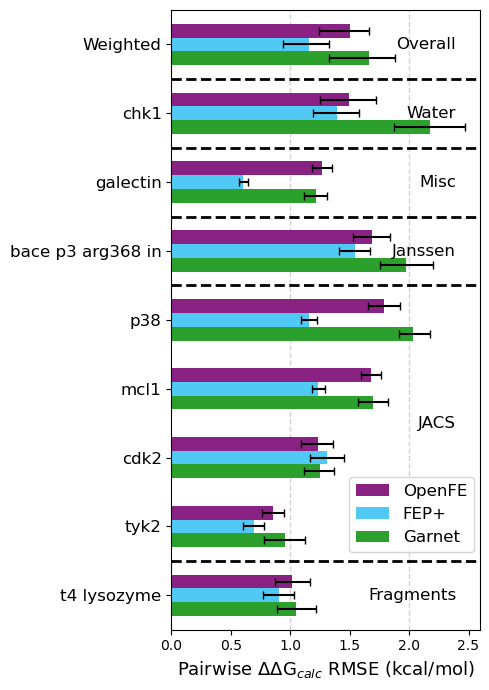

In [10]:
# plot the pairwise RMSE for OpenFE and FEP+ and Garnet with 95% CI for each system and the weighted RMSE, vertically

def plot_vertical_rmse_comparison(system_metrics, label1, label2, label3, filename, colour1, colour2, colour3):
 
    x = np.arange(len(system_metrics))

    fig, ax = plt.subplots(figsize=(5, 7))
    bar_width = 0.2

    # Plot bars with error bars
    rmse_err_openfe = [system_metrics[label1 + ' RMSE'] - system_metrics[label1 + ' RMSE_lower'], system_metrics[label1 + ' RMSE_upper'] - system_metrics[label1 + ' RMSE']]
    rmse_err_plus = [system_metrics[label2 + ' RMSE'] - system_metrics[label2 + ' RMSE_lower'], system_metrics[label2 + ' RMSE_upper'] - system_metrics[label2 + ' RMSE']]
    rmse_err_garnet = [system_metrics[label3 + ' RMSE'] - system_metrics[label3 + ' RMSE_lower'], system_metrics[label3 + ' RMSE_upper'] - system_metrics[label3 + ' RMSE']]

    ax.barh(x + bar_width, system_metrics[label1 + ' RMSE'], xerr=rmse_err_openfe, height=bar_width, label=label1, color=colour1, capsize=3)
    ax.barh(x, system_metrics[label2 + ' RMSE'], xerr=rmse_err_plus, height=bar_width, label=label2, color=colour2, capsize=3)
    ax.barh(x - bar_width, system_metrics[label3 + ' RMSE'], xerr=rmse_err_garnet, height=bar_width, label=label3, color=colour3, capsize=3)

    # Set labels and ticks
    ax.set_yticks(x)
    names = system_metrics['System'].str.replace("_", " ")
    # trim off names that are too long
    names = [name.replace("prospective", "prosp") for name in names]
    print(names)
    ax.set_yticklabels(names, fontsize=12)
    ax.set_xlabel(r"Pairwise $\Delta\Delta$G$_{calc}$ RMSE (kcal/mol)", fontsize=13)
    ax.legend(fontsize=12, bbox_to_anchor=(0.55, 0.26))

    # Add Ross et al collection names to the right of the bars
    unique_classes = system_metrics['Class'].unique()
    unique_classes = [cls for cls in unique_classes if cls != "Overall"]
    unique_classes.append("Overall")
    class_bounds = system_metrics.groupby('Class').size().cumsum().to_dict()
    class_bounds["Overall"] = len(system_metrics) + 1

    for cls, bound in class_bounds.items():
        if cls == "Overall":
            continue
        class_bounds[cls] = bound - 1
    class_start = 0

    # convert the names to more readable format
    class_conversion = {"bayer_macrocycles": "Bayer\nMacrocycles", "charge_annihilation_set": "Charge\nAnnihilation", "fragments": "Fragments", "jacs_set": "JACS", "janssen_bace": "Janssen", "merck": "Merck", "miscellaneous_set": "Misc", "scaffold_hopping_set": "Scaffold Hopping", "water_set": "Water", "mcs_docking_set": "MCS Docking"}
    for i, cls in enumerate(unique_classes):
        cls_name = class_conversion.get(cls, cls)
        end = class_bounds[cls]
        if cls != "fragments":
            ax.axhline(class_start - 0.5, linestyle='--', linewidth=2, color="black")
        if cls == "Overall":
                # move the text to fit in the space
                center = class_start
        else:
            center = (class_start + end - 1) / 2
        ax.text(ax.get_xlim()[1] - 0.2, center, cls_name, va='center', ha='right', fontsize=12, rotation=0)
        class_start = end

    # add vertical light grey dashed lines at each integer value
    for i in range(1, int(ax.get_xlim()[1]) + 1):
        ax.axvline(i, linestyle='--', color='lightgrey', linewidth=1, zorder=0)

    plt.tight_layout()
    plt.ylim(-0.5, len(system_metrics) - 0.5)
    plt.savefig(filename, dpi=300, bbox_inches='tight')

plot_vertical_rmse_comparison(dg_system_metrics, "OpenFE", "FEP+", "Garnet", "../figures/rmse_comparison.png", openfe_color, fep_plus_color, garnet_color)

# Evaluation of DG with Kendall's tau 

In [11]:
# make a new dataframe with the per system kendall tau values for openfe and FEP+ and Garnet and plot for the Hahn systems
# must have at least 16 ligands and a range of experimental values of at least 3 kcal/mol  
# this analysis uses the dG values rather than the ddG values, but the absolute numbers do not matter

from scipy.stats import kendalltau

kendall_system_metrics = []

# loop over system groups
for system in dg_data_openfe["system group"].unique():
    
    # get the edges for these systems
    system_df = dg_data_openfe[dg_data_openfe["system group"] == system].copy(deep=True).reset_index(drop=True)

    # loop over protein targets in system group
    targets = system_df["system name"].unique()
    for target in targets:
        
        # get the edges for this target
        target_df = system_df[(system_df["system name"] == target)].copy(deep=True).reset_index(drop=True)
        
        if len(target_df) < 16:
            continue
        if abs(target_df["Exp DG (kcal/mol)"].max() - target_df["Exp DG (kcal/mol)"].min()) < 3:
            continue 
            
        target_data = {"System": target, "Class": system, "N_ligs": len(target_df)}
        
        # calculate kendalltau
        tau_openfe, p_value_openfe = kendalltau(target_df["Exp DG (kcal/mol)"], target_df["DG (kcal/mol)"])
        tau_garnet, p_value_garnet = kendalltau(target_df["Exp DG (kcal/mol)"], target_df["Garnet DG (kcal/mol)"])
        tau_fep_plus, p_value_fep_plus = kendalltau(target_df["Exp DG (kcal/mol)"], target_df["FEP+ DG (kcal/mol)"])
        tau_mmgbsa, p_value_mmgbsa = kendalltau(target_df["Exp DG (kcal/mol)"], target_df["DG MMGBSA"])
        
        # bootstrap the kendall tau values
        nbootstrap = 1000
        openfe_tau = np.zeros(nbootstrap)
        garnet_tau = np.zeros(nbootstrap)
        fep_plus_tau = np.zeros(nbootstrap)
        mmgbsa_tau = np.zeros(nbootstrap)
        
        for i in range(nbootstrap):
            sample_df = target_df.sample(frac=1, replace=True)
            openfe_tau[i], _ = kendalltau(sample_df["Exp DG (kcal/mol)"], sample_df["DG (kcal/mol)"])
            garnet_tau[i], _ = kendalltau(sample_df["Exp DG (kcal/mol)"], sample_df["Garnet DG (kcal/mol)"])
            fep_plus_tau[i], _ = kendalltau(sample_df["Exp DG (kcal/mol)"], sample_df["FEP+ DG (kcal/mol)"])
            mmgbsa_tau[i], _ = kendalltau(sample_df["Exp DG (kcal/mol)"], sample_df["DG MMGBSA"])
            
        # calculate the mean and CI
        s_openfe = {
            "low": np.percentile(openfe_tau, 2.5),
            "high": np.percentile(openfe_tau, 97.5)
        }
        s_garnet = {
            "low": np.percentile(garnet_tau, 2.5),
            "high": np.percentile(garnet_tau, 97.5)
        }
        s_fep_plus = {
            "low": np.percentile(fep_plus_tau, 2.5),
            "high": np.percentile(fep_plus_tau, 97.5)
        }
        s_mmgbsa = {
            "low": np.percentile(mmgbsa_tau, 2.5),
            "high": np.percentile(mmgbsa_tau, 97.5)
        }
        
        target_data["OpenFE Kendall Tau"] = tau_openfe
        target_data["OpenFE Kendall Tau_lower"] = s_openfe["low"]
        target_data["OpenFE Kendall Tau_upper"] = s_openfe["high"]
        target_data["Garnet Kendall Tau"] = tau_garnet
        target_data["Garnet Kendall Tau_lower"] = s_garnet["low"]
        target_data["Garnet Kendall Tau_upper"] = s_garnet["high"]
        target_data["FEP+ Kendall Tau"] = tau_fep_plus
        target_data["FEP+ Kendall Tau_lower"] = s_fep_plus["low"]
        target_data["FEP+ Kendall Tau_upper"] = s_fep_plus["high"]
        target_data["MMGBSA Kendall Tau"] = tau_mmgbsa
        target_data["MMGBSA Kendall Tau_lower"] = s_mmgbsa["low"]
        target_data["MMGBSA Kendall Tau_upper"] = s_mmgbsa["high"]
        
        # add the data to a new dataframe
        kendall_system_metrics.append(target_data)
        
kendall_system_metrics = pd.DataFrame(kendall_system_metrics)
kendall_system_metrics.sort_values(by=['Class', 'OpenFE Kendall Tau'], inplace=True)
kendall_system_metrics

,System,Class,N_ligs,OpenFE Kendall Tau,OpenFE Kendall Tau_lower,OpenFE Kendall Tau_upper,Garnet Kendall Tau,Garnet Kendall Tau_lower,Garnet Kendall Tau_upper,FEP+ Kendall Tau,FEP+ Kendall Tau_lower,FEP+ Kendall Tau_upper,MMGBSA Kendall Tau,MMGBSA Kendall Tau_lower,MMGBSA Kendall Tau_upper
2,p38,jacs_set,34,0.314191,0.069568,0.521545,0.446655,0.238884,0.648059,0.542688,0.351051,0.703195,0.360040,0.132466,0.558551
1,mcl1,jacs_set,42,0.512791,0.334067,0.654287,0.385578,0.151988,0.599893,0.515716,0.317232,0.681763,0.408853,0.250840,0.544595
0,cdk2,jacs_set,16,0.633333,0.369346,0.861137,0.666667,0.385861,0.858407,0.443519,0.127216,0.761101,-0.466667,-0.688144,-0.167885
3,tyk2,jacs_set,16,0.683333,0.380531,0.886792,0.695015,0.371971,0.943400,0.811723,0.589377,0.964294,0.778249,0.587637,0.925943
4,bace_p3_arg368_in,janssen_bace,21,0.447619,0.148713,0.706535,0.469801,0.121856,0.721020,0.558474,0.275857,0.758446,0.371429,0.047073,0.673505
5,galectin,miscellaneous_set,26,0.585151,0.335978,0.773998,0.429743,0.144278,0.686294,0.661494,0.464691,0.813726,0.553128,0.323107,0.758214


In [12]:
# calculate weighted average for kendall's tau and bootstrap confidence interval

nboots = 1000

openfe_tau, garnet_tau, fep_plus_tau, mmgbsa_tau = np.zeros(nboots), np.zeros(nboots), np.zeros(nboots), np.zeros(nboots)

for i in range(nboots):
    
    # bootstrap the data (randomly selecting n systems from dataframe with replacement)
    indices = np.random.choice(len(kendall_system_metrics), size=len(kendall_system_metrics), replace=True)
    sampled_tau_df = kendall_system_metrics.iloc[indices]

    openfe_tau[i] = np.sum(sampled_tau_df['OpenFE Kendall Tau'] * sampled_tau_df['N_ligs']) / np.sum(sampled_tau_df['N_ligs'])
    garnet_tau[i] = np.sum(sampled_tau_df['Garnet Kendall Tau'] * sampled_tau_df['N_ligs']) / np.sum(sampled_tau_df['N_ligs'])
    fep_plus_tau[i] = np.sum(sampled_tau_df['FEP+ Kendall Tau'] * sampled_tau_df['N_ligs']) / np.sum(sampled_tau_df['N_ligs'])
    mmgbsa_tau[i] = np.sum(sampled_tau_df['MMGBSA Kendall Tau'] * sampled_tau_df['N_ligs']) / np.sum(sampled_tau_df['N_ligs'])
    
row_data = {
    "System": "Weighted",
    "Class": "Overall",
    "N_ligs": len(kendall_system_metrics),
    "OpenFE Kendall Tau": np.sum(kendall_system_metrics['OpenFE Kendall Tau'] * kendall_system_metrics['N_ligs']) / np.sum(kendall_system_metrics['N_ligs']),
    "OpenFE Kendall Tau_lower": np.percentile(openfe_tau, 2.5),
    "OpenFE Kendall Tau_upper": np.percentile(openfe_tau, 97.5),
    "Garnet Kendall Tau": np.sum(kendall_system_metrics['Garnet Kendall Tau'] * kendall_system_metrics['N_ligs']) / np.sum(kendall_system_metrics['N_ligs']),
    "Garnet Kendall Tau_lower": np.percentile(garnet_tau, 2.5),
    "Garnet Kendall Tau_upper": np.percentile(garnet_tau, 97.5),
    "FEP+ Kendall Tau": np.sum(kendall_system_metrics['FEP+ Kendall Tau'] * kendall_system_metrics['N_ligs']) / np.sum(kendall_system_metrics['N_ligs']),
    "FEP+ Kendall Tau_lower": np.percentile(fep_plus_tau, 2.5),
    "FEP+ Kendall Tau_upper": np.percentile(fep_plus_tau, 97.5),
    "MMGBSA Kendall Tau": np.sum(kendall_system_metrics['MMGBSA Kendall Tau'] * kendall_system_metrics['N_ligs']) / np.sum(kendall_system_metrics['N_ligs']),
    "MMGBSA Kendall Tau_lower": np.percentile(mmgbsa_tau, 2.5),
    "MMGBSA Kendall Tau_upper": np.percentile(mmgbsa_tau, 97.5),  
}

# add the row to the dataframe using concat
kendall_system_metrics = pd.concat([kendall_system_metrics, pd.DataFrame([row_data])], ignore_index=True)
kendall_system_metrics

,System,Class,N_ligs,OpenFE Kendall Tau,OpenFE Kendall Tau_lower,OpenFE Kendall Tau_upper,Garnet Kendall Tau,Garnet Kendall Tau_lower,Garnet Kendall Tau_upper,FEP+ Kendall Tau,FEP+ Kendall Tau_lower,FEP+ Kendall Tau_upper,MMGBSA Kendall Tau,MMGBSA Kendall Tau_lower,MMGBSA Kendall Tau_upper
0,p38,jacs_set,34,0.314191,0.069568,0.521545,0.446655,0.238884,0.648059,0.542688,0.351051,0.703195,0.360040,0.132466,0.558551
1,mcl1,jacs_set,42,0.512791,0.334067,0.654287,0.385578,0.151988,0.599893,0.515716,0.317232,0.681763,0.408853,0.250840,0.544595
2,cdk2,jacs_set,16,0.633333,0.369346,0.861137,0.666667,0.385861,0.858407,0.443519,0.127216,0.761101,-0.466667,-0.688144,-0.167885
3,tyk2,jacs_set,16,0.683333,0.380531,0.886792,0.695015,0.371971,0.943400,0.811723,0.589377,0.964294,0.778249,0.587637,0.925943
4,bace_p3_arg368_in,janssen_bace,21,0.447619,0.148713,0.706535,0.469801,0.121856,0.721020,0.558474,0.275857,0.758446,0.371429,0.047073,0.673505
5,galectin,miscellaneous_set,26,0.585151,0.335978,0.773998,0.429743,0.144278,0.686294,0.661494,0.464691,0.813726,0.553128,0.323107,0.758214
6,Weighted,Overall,6,0.502583,0.406079,0.610585,0.478752,0.417735,0.584770,0.574981,0.518210,0.666827,0.365031,0.110111,0.541003


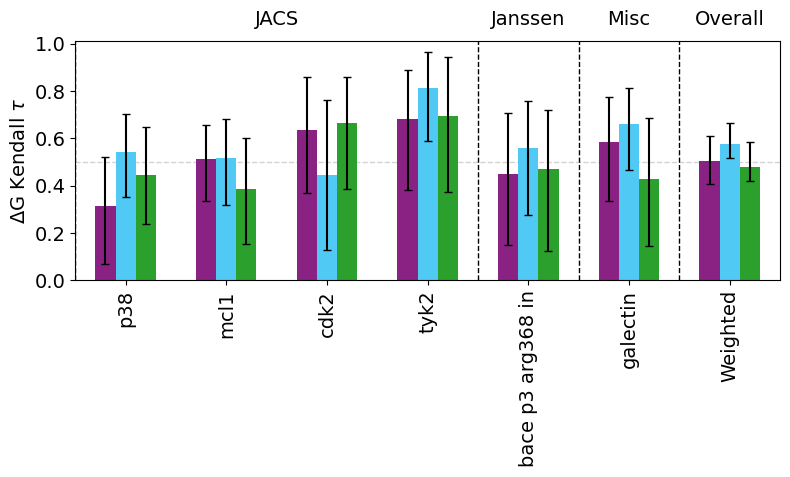

In [13]:
# plot the kendall tau values for OpenFE, FEP+  and Garnet with 95% CI for each system 

x = np.arange(len(kendall_system_metrics))

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.2

# Plot bars with error bars
tau_openfe = [kendall_system_metrics['OpenFE Kendall Tau'] - kendall_system_metrics['OpenFE Kendall Tau_lower'], kendall_system_metrics['OpenFE Kendall Tau_upper'] - kendall_system_metrics['OpenFE Kendall Tau']]
tau_fep_plus = [kendall_system_metrics['FEP+ Kendall Tau'] - kendall_system_metrics['FEP+ Kendall Tau_lower'], kendall_system_metrics['FEP+ Kendall Tau_upper'] - kendall_system_metrics['FEP+ Kendall Tau']]
tau_garnet = [kendall_system_metrics['Garnet Kendall Tau'] - kendall_system_metrics['Garnet Kendall Tau_lower'], kendall_system_metrics['Garnet Kendall Tau_upper'] - kendall_system_metrics['Garnet Kendall Tau']]

ax.bar(x - bar_width, kendall_system_metrics['OpenFE Kendall Tau'], yerr=tau_openfe, width=bar_width, label='OpenFE', color=openfe_color, capsize=3)
ax.bar(x, kendall_system_metrics['FEP+ Kendall Tau'], yerr=tau_fep_plus, width=bar_width, label='FEP+', color=fep_plus_color, capsize=3)
ax.bar(x + bar_width, kendall_system_metrics['Garnet Kendall Tau'], yerr=tau_garnet, width=bar_width, label='Garnet', color=garnet_color, capsize=3)

# Set labels and ticks
ax.set_xticks(x)
names = kendall_system_metrics['System'].str.replace("_", " ")
ax.set_xticklabels(names, rotation=90, fontsize=14)
ax.set_ylabel(r"$\Delta$G Kendall $\tau$", fontsize=14)
ax.tick_params(axis='y', labelsize=14)

unique_classes = kendall_system_metrics['Class'].unique()
unique_classes = [cls for cls in unique_classes if cls != "Overall"]
unique_classes.append("Overall")
class_bounds = kendall_system_metrics.groupby('Class').size().cumsum().to_dict()
class_bounds["Overall"] = len(kendall_system_metrics) + 1

for cls, bound in class_bounds.items():
    if cls == "Overall":
        continue
    class_bounds[cls] = bound - 1
class_start = 0

# convert the names to more readable format
class_conversion = {"bayer_macrocycles": "Bayer\nMacrocycles", "charge_annihilation_set": "Charge\nAnnihilation", "fragments": "Fragments", "jacs_set": "JACS", "janssen_bace": "Janssen", "merck": "Merck", "miscellaneous_set": "Misc", "scaffold_hopping_set": "Scaffold Hopping", "water_set": "Water", "mcs_docking_set": "MCS Docking"}
for i, cls in enumerate(unique_classes):
    cls_name = class_conversion.get(cls, cls)
    end = class_bounds[cls]
    if cls != "fragments":
        ax.axvline(class_start - 0.5, linestyle='--', linewidth=1, color="black")
    if cls == "Overall":
        # move the text to fit in the space
        center = class_start
    else:
        center = (class_start + end - 1) / 2
    ax.text(center, ax.get_ylim()[1] + 0.09, cls_name, ha='center', va='center', fontsize=14)
    class_start = end

# add horizontal light grey dashed line at 0.5
ax.axhline(0.5, linestyle='--', color='lightgrey', linewidth=1, zorder=0)

plt.tight_layout()
plt.xlim(-0.5, len(kendall_system_metrics) - 0.5)
plt.savefig("../figures/tau_comparison.png", dpi=300, bbox_inches='tight')

# Evaluation of DG with Fraction of Best Ligands

In [14]:
# calculate the fraction of best ligands metric for each of the hahn systems
# this code is taken from PR <https://github.com/OpenFreeEnergy/cinnabar/pull/122>

import math
def _create_2d_histogram(y_true, y_pred):
    """
    Metric inspired by the talk of Chris Bailey on alchemistry 2024
    Create a 2D histogram from two arrays of data.
    Parameters
    ----------
    y_true : array-like
        The true values.
    y_pred : array-like
        The predicted values.
    Returns,
    -------
    histogram : ndarray
        The 2D histogram of the input data.
    bins_true : ndarray
        The bin edges along the y_true axis.
    bins_pred : ndarray
        The bin edges along the y_pred axis.
    Raises
    ------
    ValueError
        If `y_true` and `y_pred` have different lengths.
    TypeError
        If `y_true` or `y_pred` cannot be converted to numpy arrays.
    """
    try:
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
    except Exception as e:
        raise TypeError("Input data cannot be converted to numpy arrays.") from e

    if y_true.shape != y_pred.shape:
        raise ValueError("y_true and y_pred must have the same length.")

    y_true_sorted = np.sort(y_true)
    y_pred_sorted = np.sort(y_pred)

    bins_true = np.concatenate(([y_true.min()], (y_true_sorted[:-1] + y_true_sorted[1:]) / 2, [y_true.max()]))
    bins_pred = np.concatenate(([y_pred.min()], (y_pred_sorted[:-1] + y_pred_sorted[1:]) / 2, [y_pred.max()]))

    histogram, bins_true, bins_pred = np.histogram2d(y_true, y_pred, bins=[bins_true, bins_pred])

    return histogram, bins_true, bins_pred

def _compute_overlap_coefficient(histogram, ranking):
    """
    Compute the overlap coefficient from a 2D histogram.
    The overlap coefficient is calculated based on the counts in the histogram
    for the top N ranked ligands (most active).
    Parameters
    ----------
    histogram : ndarray
        A 2D histogram array where the counts are stored.
    ranking : int
        The number of rankings to consider when computing overlap.
    Returns
    -------
    float
        The overlap coefficient.
    Raises
    ------
    ValueError
        If `top_n_ligands` is greater than the number of ligands in the histogram.
    """
    if ranking < 1:
        raise ValueError("Ranking must be greater than 0.")

    if histogram.shape[0] < ranking:
        raise ValueError("Ranking must be less than the number of ligands.")

    overlap = np.sum(histogram[:ranking, :ranking])

    return overlap / ranking
    
def compute_fraction_best_ligands(y_true, y_pred, fraction=0.5):
    """
    Compute the fraction of the best ligands metric introduced by Chris Bayly.
    This function calculates the fraction of the best ligands by computing overlap 
    coefficients for each ranking up to the number of ligands and then averaging up to the specified fraction.
    Parameters
    ----------
    y_true : array-like
        The true values.
    y_pred : array-like
        The predicted values.
    fraction : float, optional
        The fraction of ligands to consider as the best (default is 0.5).
    Returns
    -------
    float
        The computed fraction of the best ligands.
    Raises
    ------
    ValueError
        If `fraction` is not between 0 and 1.
    """

    if not (0 <= fraction <= 1):
        raise ValueError("Fraction must be between 0 and 1.")

    histogram = _create_2d_histogram(y_true, y_pred)[0]
    num_ligands = histogram.shape[0]
    num_best_ligands = math.floor(num_ligands * fraction)

    overlap_coefficients = [_compute_overlap_coefficient(histogram, i + 1) for i in range(num_ligands)]
    best_coefficients = overlap_coefficients[:num_best_ligands]

    fraction_best_ligands = sum(best_coefficients) / num_best_ligands

    return fraction_best_ligands

fraction_best_system_metrics = []

# loop over system groups
for system in dg_data_openfe["system group"].unique():
    
    # get the edges for these systems
    system_df = dg_data_openfe[dg_data_openfe["system group"] == system].copy(deep=True).reset_index(drop=True)
    targets = system_df["system name"].unique()

    # loop over target protein in each system
    for target in targets:
        
        # get the edges for this target
        target_df = system_df[(system_df["system name"] == target)].copy(deep=True).reset_index(drop=True)
        if len(target_df) < 16:
            continue
        if abs(target_df["Exp DG (kcal/mol)"].max() - target_df["Exp DG (kcal/mol)"].min()) < 3:
            continue 
            
        target_data = {"System": target, "Class": system, "N_ligs": len(target_df)}
        
        # calculate the fraction of best ligands for OpenFE and FEP+ and Garnet
        target_data["OpenFE Fraction Best"] = compute_fraction_best_ligands(target_df["Exp DG (kcal/mol)"], target_df["DG (kcal/mol)"])
        target_data["Garnet Fraction Best"] = compute_fraction_best_ligands(target_df["Exp DG (kcal/mol)"], target_df["Garnet DG (kcal/mol)"])
        target_data["FEP+ Fraction Best"] = compute_fraction_best_ligands(target_df["Exp DG (kcal/mol)"], target_df["FEP+ DG (kcal/mol)"])
        target_data["MMGBSA Fraction Best"] = compute_fraction_best_ligands(target_df["Exp DG (kcal/mol)"], target_df["DG MMGBSA"])
        
        # add the data to a new dataframe
        fraction_best_system_metrics.append(target_data)
        
fraction_best_system_metrics = pd.DataFrame(fraction_best_system_metrics)
fraction_best_system_metrics.sort_values(by=['Class', 'OpenFE Fraction Best'], inplace=True)
fraction_best_system_metrics

,System,Class,N_ligs,OpenFE Fraction Best,Garnet Fraction Best,FEP+ Fraction Best,MMGBSA Fraction Best
2,p38,jacs_set,34,0.451312,0.520540,0.503539,0.410455
1,mcl1,jacs_set,42,0.532683,0.522592,0.567679,0.349389
3,tyk2,jacs_set,16,0.627976,0.790476,0.785268,0.597768
0,cdk2,jacs_set,16,0.718601,0.740625,0.567560,0.049107
4,bace_p3_arg368_in,janssen_bace,21,0.556032,0.665714,0.464643,0.406310
5,galectin,miscellaneous_set,26,0.620908,0.543178,0.659369,0.488338


In [15]:
# calculate weighted average for FBL and bootstrap confidence interval

nboots = 1000

openfe_fbl, garnet_fbl, fep_plus_fbl, mmgbsa_fbl = np.zeros(nboots), np.zeros(nboots), np.zeros(nboots), np.zeros(nboots)

for i in range(nboots):
    
    # bootstrap the data (randomly selecting n systems from dataframe with replacement)
    indices = np.random.choice(len(fraction_best_system_metrics), size=len(fraction_best_system_metrics), replace=True)
    sampled_fbl_df = fraction_best_system_metrics.iloc[indices]

    openfe_fbl[i] = np.sum(sampled_fbl_df['OpenFE Fraction Best'] * sampled_fbl_df['N_ligs']) / np.sum(sampled_fbl_df['N_ligs'])
    garnet_fbl[i] = np.sum(sampled_fbl_df['Garnet Fraction Best'] * sampled_fbl_df['N_ligs']) / np.sum(sampled_fbl_df['N_ligs'])
    fep_plus_fbl[i] = np.sum(sampled_fbl_df['FEP+ Fraction Best'] * sampled_fbl_df['N_ligs']) / np.sum(sampled_fbl_df['N_ligs'])
    mmgbsa_fbl[i] = np.sum(sampled_fbl_df['MMGBSA Fraction Best'] * sampled_fbl_df['N_ligs']) / np.sum(sampled_fbl_df['N_ligs'])
    
row_data = {
    "System": "Weighted",
    "Class": "Overall",
    "N_ligs": len(fraction_best_system_metrics),
    "OpenFE Fraction Best": np.sum(fraction_best_system_metrics['OpenFE Fraction Best'] * fraction_best_system_metrics['N_ligs']) / np.sum(fraction_best_system_metrics['N_ligs']),
    "OpenFE Fraction Best_lower": np.percentile(openfe_fbl, 2.5),
    "OpenFE Fraction Best_upper": np.percentile(openfe_fbl, 97.5),
    "Garnet Fraction Best": np.sum(fraction_best_system_metrics['Garnet Fraction Best'] * fraction_best_system_metrics['N_ligs']) / np.sum(fraction_best_system_metrics['N_ligs']),
    "Garnet Fraction Best_lower": np.percentile(garnet_fbl, 2.5),
    "Garnet Fraction Best_upper": np.percentile(garnet_fbl, 97.5),
    "FEP+ Fraction Best": np.sum(fraction_best_system_metrics['FEP+ Fraction Best'] * fraction_best_system_metrics['N_ligs']) / np.sum(fraction_best_system_metrics['N_ligs']),
    "FEP+ Fraction Best_lower": np.percentile(fep_plus_fbl, 2.5),
    "FEP+ Fraction Best_upper": np.percentile(fep_plus_fbl, 97.5),
    "MMGBSA Fraction Best": np.sum(fraction_best_system_metrics['MMGBSA Fraction Best'] * fraction_best_system_metrics['N_ligs']) / np.sum(fraction_best_system_metrics['N_ligs']),
    "MMGBSA Fraction Best_lower": np.percentile(mmgbsa_fbl, 2.5),
    "MMGBSA Fraction Best_upper": np.percentile(mmgbsa_fbl, 97.5),  
}

# add the row to the dataframe using concat
fraction_best_system_metrics = pd.concat([fraction_best_system_metrics, pd.DataFrame([row_data])], ignore_index=True)
fraction_best_system_metrics

,System,Class,N_ligs,OpenFE Fraction Best,Garnet Fraction Best,FEP+ Fraction Best,MMGBSA Fraction Best,OpenFE Fraction Best_lower,OpenFE Fraction Best_upper,Garnet Fraction Best_lower,Garnet Fraction Best_upper,FEP+ Fraction Best_lower,FEP+ Fraction Best_upper,MMGBSA Fraction Best_lower,MMGBSA Fraction Best_upper
0,p38,jacs_set,34,0.451312,0.520540,0.503539,0.410455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,mcl1,jacs_set,42,0.532683,0.522592,0.567679,0.349389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,tyk2,jacs_set,16,0.627976,0.790476,0.785268,0.597768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,cdk2,jacs_set,16,0.718601,0.740625,0.567560,0.049107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bace_p3_arg368_in,janssen_bace,21,0.556032,0.665714,0.464643,0.406310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,galectin,miscellaneous_set,26,0.620908,0.543178,0.659369,0.488338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Weighted,Overall,6,0.561825,0.595145,0.577479,0.388446,0.5055,0.637843,0.53936,0.687452,0.519996,0.663766,0.283216,0.482087


In [16]:
order = ["p38", "mcl1", "cdk2","tyk2","bace_p3_arg368_in","galectin","Weighted"]
fraction_best_system_metrics = fraction_best_system_metrics.set_index("System").loc[order].reset_index()

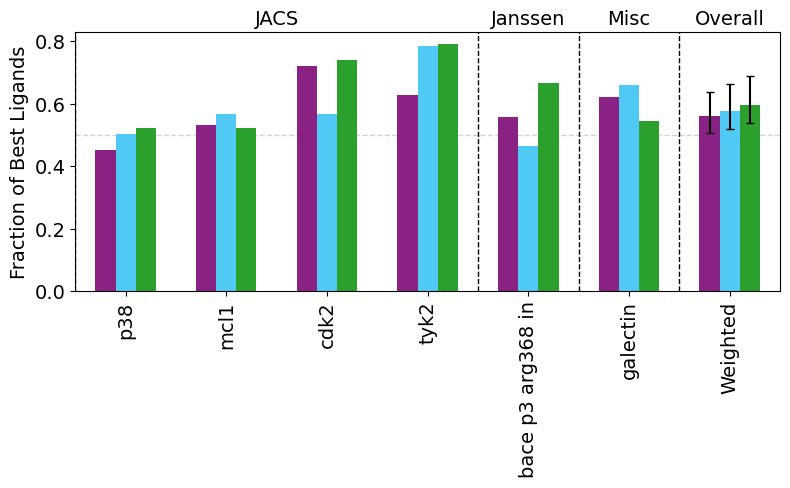

In [17]:
# plot the fraction of best ligands for OpenFE and FEP+ and Garnet

x = np.arange(len(fraction_best_system_metrics))

# Set up the figure
fig, ax = plt.subplots(figsize=(8, 5))
bar_width = 0.2

# Define error bars
fbl_openfe = [fraction_best_system_metrics['OpenFE Fraction Best'] - fraction_best_system_metrics['OpenFE Fraction Best_lower'], fraction_best_system_metrics['OpenFE Fraction Best_upper'] - fraction_best_system_metrics['OpenFE Fraction Best']]
fbl_fep_plus = [fraction_best_system_metrics['FEP+ Fraction Best'] - fraction_best_system_metrics['FEP+ Fraction Best_lower'], fraction_best_system_metrics['FEP+ Fraction Best_upper'] - fraction_best_system_metrics['FEP+ Fraction Best']]
fbl_garnet = [fraction_best_system_metrics['Garnet Fraction Best'] - fraction_best_system_metrics['Garnet Fraction Best_lower'], fraction_best_system_metrics['Garnet Fraction Best_upper'] - fraction_best_system_metrics['Garnet Fraction Best']]

# Plot bars with error bars
ax.bar(x - bar_width, fraction_best_system_metrics['OpenFE Fraction Best'], yerr=fbl_openfe, width=bar_width, label='OpenFE', color=openfe_color, capsize=3)
ax.bar(x, fraction_best_system_metrics['FEP+ Fraction Best'], yerr=fbl_fep_plus, width=bar_width, label='FEP+', color=fep_plus_color, capsize=3)
ax.bar(x + bar_width, fraction_best_system_metrics['Garnet Fraction Best'], yerr=fbl_garnet, width=bar_width, label='Garnet', color=garnet_color, capsize=3)

# Set labels and ticks
ax.set_xticks(x)
names = fraction_best_system_metrics['System'].str.replace("_", " ")
ax.set_xticklabels(names, rotation=90, fontsize=14)
ax.set_ylabel(r"Fraction of Best Ligands", fontsize=14)
#ax.legend(fontsize=16)
# make y ticks bigger
ax.tick_params(axis='y', labelsize=14)

# code below useful for plotting with the 'overall' category
# taken from rmse plotting code
unique_classes = fraction_best_system_metrics['Class'].unique()
unique_classes = [cls for cls in unique_classes if cls != "Overall"]
unique_classes.append("Overall")
class_bounds = fraction_best_system_metrics.groupby('Class').size().cumsum().to_dict()
class_bounds["Overall"] = len(fraction_best_system_metrics) + 1

for cls, bound in class_bounds.items():
    if cls == "Overall":
        continue
    class_bounds[cls] = bound - 1
class_start = 0

# convert the names to more readable format
class_conversion = {"bayer_macrocycles": "Bayer\nMacrocycles", "charge_annihilation_set": "Charge\nAnnihilation", "fragments": "Fragments", "jacs_set": "JACS", "janssen_bace": "Janssen", "merck": "Merck", "miscellaneous_set": "Misc", "scaffold_hopping_set": "Scaffold Hopping", "water_set": "Water", "mcs_docking_set": "MCS Docking"}
for i, cls in enumerate(unique_classes):
    cls_name = class_conversion.get(cls, cls)
    end = class_bounds[cls]
    if cls != "fragments":
        ax.axvline(class_start - 0.5, linestyle='--', linewidth=1, color="black")
    if cls == "Overall":
        # move the text to fit in the space
        center = class_start
    else:
        center = (class_start + end - 1) / 2
    ax.text(center, ax.get_ylim()[1] + 0.01, cls_name, ha='center', va='bottom', fontsize=14)
    class_start = end

# add horizontal light grey dashed line at 0.5
ax.axhline(0.5, linestyle='--', color='lightgrey', linewidth=1, zorder=0)
plt.tight_layout()
plt.xlim(-0.5, len(fraction_best_system_metrics) - 0.5)
plt.savefig("../figures/fbl_comparison.png", dpi=300, bbox_inches='tight')

# Make dataframe with all pairwise ddG values

In [18]:
# make a new dataframe with all possible pairwise DDG values for openfe, fep+ and garnet
# calculate errorbars, but only for exp and garnet, by propagating the dG errors

all_pairwise_ddgs = []

# loop over system groups
for system in dg_data_openfe_full["system group"].unique():

    # get the edges for these systems
    system_df = dg_data_openfe_full[dg_data_openfe_full["system group"] == system].copy(deep=True).reset_index(drop=True)
    
    targets = system_df["system name"].unique()

    # loop over the target proteins in the system 
    for target in targets:
    
        # get the edges for this target
        target_df = system_df[(system_df["system name"] == target)].copy(deep=True).reset_index(drop=True)
        
        # get the ligands
        ligands = target_df["ligand name"].unique()

        # loop over all ligand pairs
        for i, ligand1 in enumerate(ligands):
            for j, ligand2 in enumerate(ligands):
                if i >= j:  # skip self-comparisons
                    continue
        
                # get the ddg values for these ligands
                exp_dg1 = target_df[target_df["ligand name"] == ligand1]["Exp DG (kcal/mol)"].values[0]
                exp_dg2 = target_df[target_df["ligand name"] == ligand2]["Exp DG (kcal/mol)"].values[0]
                openfe_dg1 = target_df[target_df["ligand name"] == ligand1]["DG (kcal/mol)"].values[0]
                openfe_dg2 = target_df[target_df["ligand name"] == ligand2]["DG (kcal/mol)"].values[0]
                garnet_dg1 = target_df[target_df["ligand name"] == ligand1]["Garnet DG (kcal/mol)"].values[0]
                garnet_dg2 = target_df[target_df["ligand name"] == ligand2]["Garnet DG (kcal/mol)"].values[0]
                fep_plus_dg1 = target_df[target_df["ligand name"] == ligand1]["FEP+ DG (kcal/mol)"].values[0]
                fep_plus_dg2 = target_df[target_df["ligand name"] == ligand2]["FEP+ DG (kcal/mol)"].values[0]
                mmgbsa_dg1 = target_df[target_df["ligand name"] == ligand1]["DG MMGBSA"].values[0]
                mmgbsa_dg2 = target_df[target_df["ligand name"] == ligand2]["DG MMGBSA"].values[0]

                # add errors for exp and garnet runs
                
                # get the exp ddg err for this pair (propagate individual errors)
                exp_error_a = target_df[target_df["ligand name"] == ligand1]["Exp dDG (kcal/mol)"].values[0]
                exp_error_b = target_df[target_df["ligand name"] == ligand2]["Exp dDG (kcal/mol)"].values[0]
                exp_error_ab = (exp_error_a ** 2 + exp_error_b ** 2) ** 0.5
                
                # get the prediction ddg error for this pair (propagate individual errors)
                prediction_error_a = target_df[target_df["ligand name"] == ligand1]["Garnet DG uncertainty (kcal/mol)"].values[0]
                prediction_error_b = target_df[target_df["ligand name"] == ligand2]["Garnet DG uncertainty (kcal/mol)"].values[0]
                prediction_error_ab = (prediction_error_a ** 2 + prediction_error_b ** 2) ** 0.5
                
                # add to a new dataframe
                new_row = {
                    "System": target,
                    "Class": system,
                    "Ligand 1": ligand1,
                    "Ligand 2": ligand2,
                    "Exp DDG (kcal/mol)": exp_dg2 - exp_dg1,
                    "OpenFE DDG (kcal/mol)": openfe_dg2 - openfe_dg1,
                    "Garnet DDG (kcal/mol)": garnet_dg2 - garnet_dg1,
                    "FEP+ DDG (kcal/mol)": fep_plus_dg2 - fep_plus_dg1,
                    "MMGBSA DDG (kcal/mol)": mmgbsa_dg2 - mmgbsa_dg1,
                    "Exp DDG uncertainty (kcal/mol)": exp_error_ab,
                    "Garnet DDG uncertainty (kcal/mol)": prediction_error_ab
                }
                all_pairwise_ddgs.append(new_row)
                
all_pairwise_ddgs = pd.DataFrame(all_pairwise_ddgs)
all_pairwise_ddgs.head()

,System,Class,Ligand 1,Ligand 2,Exp DDG (kcal/mol),OpenFE DDG (kcal/mol),Garnet DDG (kcal/mol),FEP+ DDG (kcal/mol),MMGBSA DDG (kcal/mol),Exp DDG uncertainty (kcal/mol),Garnet DDG uncertainty (kcal/mol)
0,t4_lysozyme,fragments,benzene,butyl benzene,-1.50,-1.784062,-1.4,-1.65,-20.2,0.0,0.583095
1,t4_lysozyme,fragments,benzene,ethyl benzene,-0.56,-1.789349,-0.4,-1.33,-11.1,0.0,0.583095
2,t4_lysozyme,fragments,benzene,isobutyl benzene,-1.28,-1.503389,-0.7,-1.59,-16.2,0.0,0.583095
3,t4_lysozyme,fragments,benzene,m-xylene,0.44,1.301786,-1.0,-0.09,-7.9,0.0,0.707107
4,t4_lysozyme,fragments,benzene,meta methyl ethyl benzene,0.08,-0.302681,-1.8,-0.81,-10.7,0.0,0.707107


# Scatter plots for supplementary material

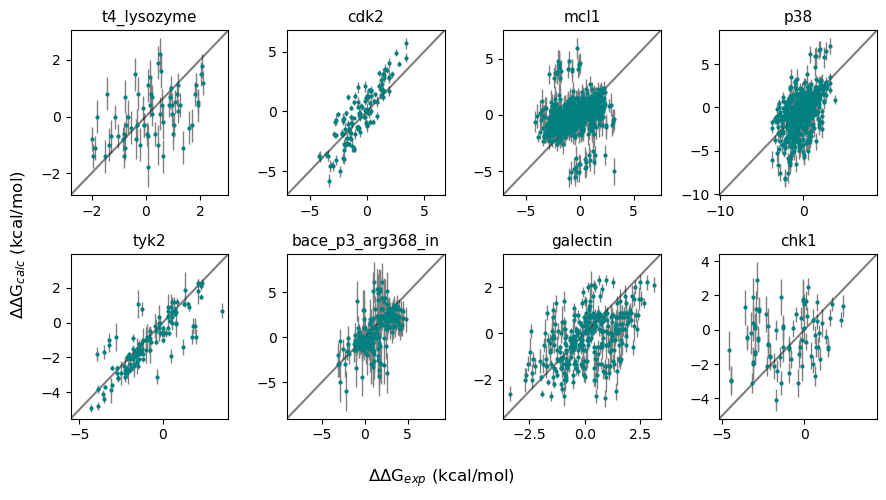

In [19]:
# plot ddG values used to calculate RMSEs to experimental data
# i.e. not all of these edges were run, these ddGs were all calculated from the calculated dG values

# create subplot grid
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(9, 5))
axes = axes.flatten()
i = 0

# loop over system groups
for system_group in all_pairwise_ddgs["Class"].unique():

    # get the edges for these systems
    system_df = all_pairwise_ddgs[all_pairwise_ddgs["Class"] == system_group].copy(deep=True).reset_index(drop=True)
    
    proteins = system_df["System"].unique()

    # loop over the target proteins in the system 
    for protein in proteins:

        if protein == "cmet":
            continue

        else:
    
            # get the edges for this target
            protein_df = system_df[(system_df["System"] == protein)].copy(deep=True).reset_index(drop=True)
    
            ddg_exp_arr = protein_df['Exp DDG (kcal/mol)'].values
            ddg_calc_arr = protein_df['Garnet DDG (kcal/mol)'].values
            ddg_calc_err_arr = protein_df['Garnet DDG uncertainty (kcal/mol)'].values
            
            axes[i].errorbar(
                x=ddg_exp_arr, y=ddg_calc_arr, yerr=ddg_calc_err_arr,
                fmt='o', elinewidth=1, markersize=2, color='teal', ecolor='grey'
            )
    
            # get x and y lims of plot 
            x_min, x_max = axes[i].get_xlim()
            y_min, y_max = axes[i].get_ylim()
            
            # choose a range that covers both axes equally
            min_lim = min(x_min, y_min)
            max_lim = max(x_max, y_max)
            axes[i].set_xlim(min_lim, max_lim)
            axes[i].set_ylim(min_lim, max_lim)
            
            # plot diagonal
            diag = np.linspace(min_lim, max_lim, 100)
            axes[i].plot(diag, diag, color='black',alpha=0.5)
            
            axes[i].set_title(f"{protein}",fontsize=11)
    
            i+=1

fig.supxlabel(r"$\Delta \Delta $G$_{exp}$ (kcal/mol)")
fig.supylabel(r"$\Delta \Delta $G$_{calc}$ (kcal/mol)")

plt.tight_layout()
plt.savefig('../figures/scatter.pdf')
plt.show()

# Analyse cmet

In [20]:
from itertools import product
import matplotlib.colors as mcolors

In [21]:
# filter dataframe to only contain results for cmet
dg_data_openfe_filter = dg_data_openfe_full[dg_data_openfe_full['system name'] == 'cmet']

In [22]:
# define the two groups of ligands that are separated by a single charge transformation edge in the ligand transformation network

# define ligands that are above the charge transformation edge in the network 
# none of these ligands have a net charge
ligands_top_network = np.array([
    'CHEMBL3402750_400','CHEMBL3402748_5300','CHEMBL3402751_2100','CHEMBL3402749_500','CHEMBL3402747_3400', 'CHEMBL3402752_30000',
    'CHEMBL3402761_1_redocked','CHEMBL3402744_300','CHEMBL3402755_4200','CHEMBL3402745_200','CHEMBL3402754_40', 'CHEMBL3402753_200'
])

# define ligands that are below the charge transformation edge in the network 
# these ligands all have a net charge of +1
ligands_bottom_network = np.array([
    'CHEMBL3402743_42','CHEMBL3402742_23','CHEMBL3402763_90','CHEMBL3402741_400', 'CHEMBL3402765_11-charged-pKa-8.1',
    'CHEMBL3402764_90','CHEMBL3402758_10_redocked','CHEMBL3402762_1_redocked','CHEMBL3402756_2.7_redocked',
    'CHEMBL3402760_1_redocked','CHEMBL3402757_6.5_redocked','CHEMBL3402759_5.7_redocked'
])

# define pairs across groups
top_bottom_list = []
for ligand_top in ligands_top_network:
    for ligand_bottom in ligands_bottom_network:
        top_bottom_list.append((ligand_top,ligand_bottom))

# define pairs across groups
bottom_top_list = []
for ligand_bottom in ligands_bottom_network:
    for ligand_top in ligands_top_network:
        bottom_top_list.append((ligand_bottom,ligand_top))

# define pairs across charge transformation
pairs_across = list(product(ligands_top_network, ligands_bottom_network))

# define pairs within top part of network
pairs_within_top = list(product(ligands_top_network, ligands_top_network))

# define pairs within bottom part of network
pairs_within_bottom = list(product(ligands_bottom_network, ligands_bottom_network))

In [23]:
# get pairwise ddg values for cmet
all_pairwise_ddgs_filtered = all_pairwise_ddgs[all_pairwise_ddgs['System'] == 'cmet']
all_pairwise_ddgs_filtered = all_pairwise_ddgs_filtered.reset_index()

# define type (with respect to network structure) of all ligand pairs
pair_type_arr = np.zeros(len(all_pairwise_ddgs_filtered))
for idx in range(len(all_pairwise_ddgs_filtered)):
    ligand_1 = all_pairwise_ddgs_filtered['Ligand 1'].iloc[idx]
    ligand_2 = all_pairwise_ddgs_filtered['Ligand 2'].iloc[idx]
    if (ligand_1, ligand_2) in top_bottom_list:
        pair_type_arr[idx] = 0
    elif (ligand_1, ligand_2) in bottom_top_list:
        pair_type_arr[idx] = 2 
    elif ((ligand_1, ligand_2) in pairs_within_top) or ((ligand_2, ligand_1) in pairs_within_top):
        pair_type_arr[idx] = 1
    elif ((ligand_1, ligand_2) in pairs_within_bottom) or ((ligand_2, ligand_1) in pairs_within_bottom):
        pair_type_arr[idx] = -1
    else:
        raise ValueError(f"Ligand pair with {ligand_1} and {ligand_2} not found.")

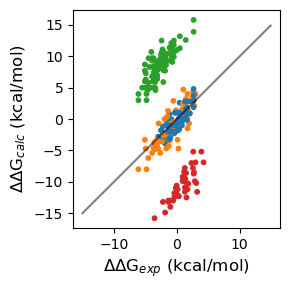

In [24]:
# red means that it is in bottom->top
# green means that it is in top->bottom
plt.figure(figsize=(3,3))
cmap = mcolors.ListedColormap(['tab:blue', 'tab:green', 'tab:orange','tab:red'])
plt.scatter(all_pairwise_ddgs_filtered['Exp DDG (kcal/mol)'], all_pairwise_ddgs_filtered['Garnet DDG (kcal/mol)'], c=pair_type_arr, cmap=cmap,s=10)
plt.xlabel(r"$\Delta \Delta $G$_{exp}$ (kcal/mol)",fontsize=12)
plt.ylabel(r"$\Delta \Delta $G$_{calc}$ (kcal/mol)",fontsize=12)
plt.plot(np.arange(-15,15,0.1),np.arange(-15,15,0.1),color='black',alpha=0.5)
plt.tight_layout()
plt.savefig("../figures/ddg_exp_calc_cmet.pdf")